# Images as Grids of Pixels

### Importing libraries

In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   -- ------------------------------------- 2.4/39.0 MB 13.4 MB/s eta 0:00:03
   ---------------- ----------------------- 15.7/39.0 MB 39.6 MB/s eta 0:00:01
   -------------------------------- ------- 31.5/39.0 MB 52.5 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 53.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 12.6/12.6 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np

# for reading in images
import matplotlib.image as mpimg

import matplotlib.pyplot as plt

# computer vision library for data manipulation in images
import cv2

%matplotlib inline

### Reading and displaying the images

In [4]:
# Read in the image
image = mpimg.imread('seven.png')

# Print out the image dimensions
print('Image dimensions:', image.shape)

Image dimensions: (1480, 1490, 4)


The key points about this image dimension information are:

**Width x Height:** The first two numbers (1480, 1490) represent the width and height of the image in pixels.
This tells you the overall size and resolution of the image.

**Color Channels:** The third number (4) indicates the number of color channels in the image. Common values are:

3 channels = RGB (red, green, blue)

4 channels = RGBA (red, green, blue, alpha/transparency)


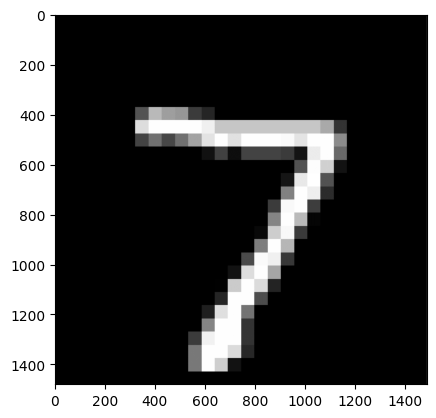

In [5]:
# to see the image again
plt.imshow(image);

First dimension stores the x-axis values, 2nd dimension stores the y-axis avlues and the third dimension represents the channel (R-G-B)

In [6]:
# the image is stored as numbers in a 3d numpy array
image[:, :, 0]

array([[0.98039216, 0.98039216, 0.7764706 , ..., 0.98039216, 1.        ,
        1.        ],
       [0.98039216, 0.98039216, 0.7764706 , ..., 0.98039216, 1.        ,
        1.        ],
       [0.7764706 , 0.7764706 , 0.        , ..., 0.7764706 , 1.        ,
        1.        ],
       ...,
       [0.89411765, 0.89411765, 0.        , ..., 0.89411765, 1.        ,
        1.        ],
       [0.8666667 , 0.8666667 , 0.        , ..., 0.8666667 , 1.        ,
        1.        ],
       [0.8666667 , 0.8666667 , 0.        , ..., 0.8666667 , 1.        ,
        1.        ]], shape=(1480, 1490), dtype=float32)

In [7]:
# Get the pixel value at row 100, column 200 in the first channel
pixel_value = image[100, 200, 0]
pixel_value

np.float32(0.0)

## Lets see each channel

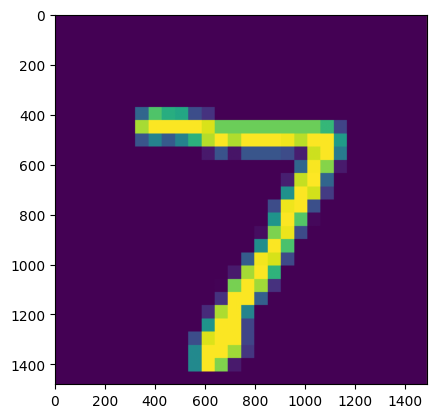

In [8]:
# 0 is red channel
red_channel = image[:, :, 0]
plt.imshow(red_channel);

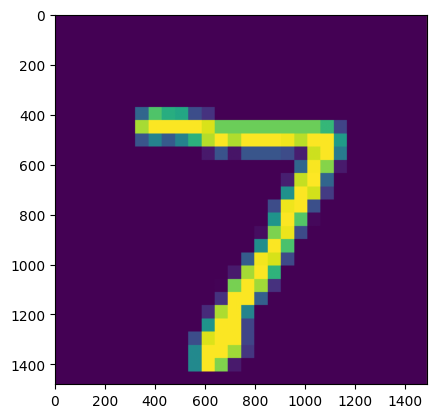

In [9]:
# 1 is green channel
green_channel = image[:, :, 1]
plt.imshow(green_channel);

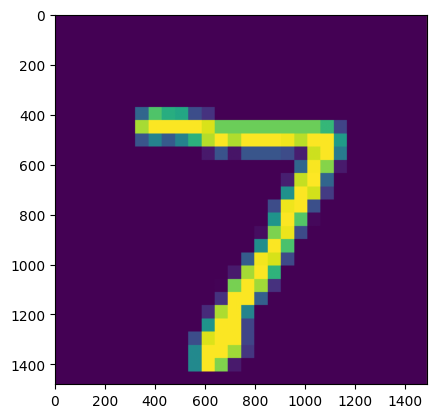

In [10]:
# 2 is green channel
blue_channel = image[:, :, 2]
plt.imshow(blue_channel);

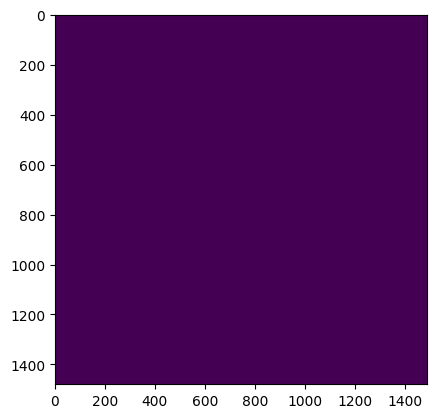

In [11]:
# 3 is transparency channel
transparent_channel = image[:, :, 3]
plt.imshow(transparent_channel);

## Image pre-processing

Original Image dimensions: (1480, 1490, 4)


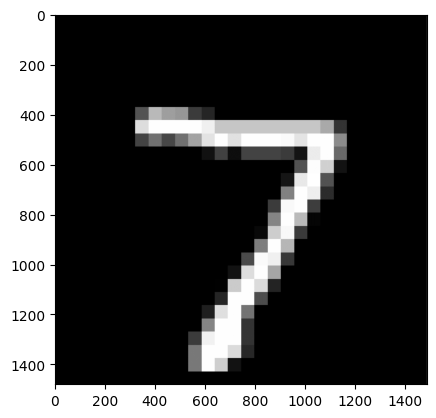

In [13]:
# Read in the image
image = mpimg.imread('seven.png')

# Print out the image dimensions
print('Original Image dimensions:', image.shape)

plt.imshow(image);

#### Convert color image to gray scale - This helps in dimentionality reduction

Grayscale Image dimensions: (1480, 1490)


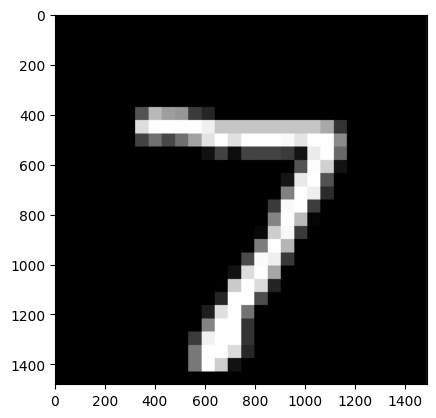

In [14]:
# Change from color to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.imshow(gray_image, cmap='gray');

print('Grayscale Image dimensions:', gray_image.shape)

Now the image has become 2 dimensional.

In [15]:
gray_image.shape

(1480, 1490)

In [16]:
# Finds the maximum and minimum grayscale values in this image

max_val = np.amax(gray_image)
min_val = np.amin(gray_image)

print('Max: ', max_val)
print('Min: ', min_val)

Max:  1.0
Min:  0.0


In [17]:
# Prints specific grayscale pixel values
# What is the pixel value at x = 400 and y = 300

x = 400
y = 300

print(gray_image[y,x])

0.0


* There will be a total of (1480x1490) pixels, and each pixel will have a number assigned to it. Therefore, each pixel becomes the input feature.

* for e.g. let's say if you had a 5x5 pixel image, you would have a total of 25 pixels and those 25 pixel values are the input features to the CNN network. See image below:


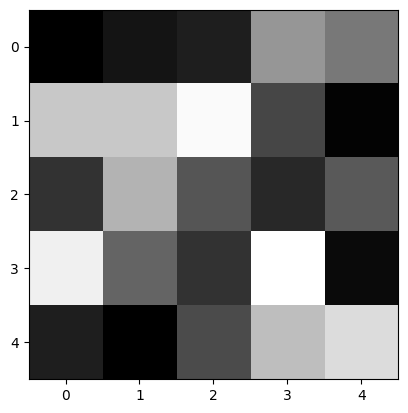

In [18]:
# Creating a 5x5 image using just grayscale, numerical values
tiny_image = np.array([[0, 20, 30, 150, 120],
                      [200, 200, 250, 70, 3],
                      [50, 180, 85, 40, 90],
                      [240, 100, 50, 255, 10],
                      [30, 0, 75, 190, 220]])

# To show the pixel grid, use matshow
plt.imshow(tiny_image, cmap='gray')

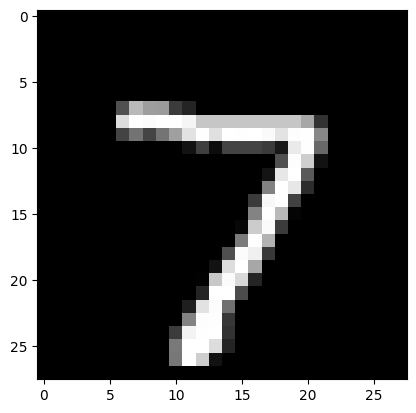

In [19]:
# Reduce the size of the image (Image downscaling)

resized_image = cv2.resize(gray_image, (28, 28))

# Display the grayscale image
plt.imshow(resized_image, cmap='gray')


In [20]:
# Finds the maximum and minimum grayscale values in this image

max_val = np.amax(resized_image)
min_val = np.amin(resized_image)

print('Max: ', max_val)
print('Min: ', min_val)

Max:  1.0
Min:  0.0


In [21]:
resized_image.shape

(28, 28)